In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, 
                                  RobustScaler, FunctionTransformer)
from sklearn.model_selection import (train_test_split, GridSearchCV, 
                                   cross_val_score)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import optuna
from sklearn.model_selection import cross_val_score
from functools import partial
import seaborn as sns

In [141]:
# 数据加载与预处理
def load_and_preprocess(file_path):
    # 加载数据
    df = pd.read_csv(file_path)
    
    # 异常值处理（价格过滤）
    price_q1 = df['Price'].quantile(0.05)
    price_q3 = df['Price'].quantile(0.95)
    df = df[(df['Price'] > price_q1) & (df['Price'] < price_q3)]
    
    # 特征工程
    current_year = pd.Timestamp.now().year
    df['Vehicle_age'] = current_year - df['Prod. year']
    df['Mileage_per_year'] = df['Mileage'] / (df['Vehicle_age'].clip(lower=1) + 1e-6)
    
    # 删除冗余特征
    df = df.drop(['ID', 'Prod. year', 'Doors', 'Color', 'Cylinders', 'Drive wheels'], axis=1, errors='ignore')
    
    return df

In [142]:
# 加载数据
df = load_and_preprocess(r"D:\GitHubRepos\is6400-business-data-analytics\data\The_boss.csv")

In [143]:
# 定义特征类型
categorical_features = ['Manufacturer', 'Fuel type', 'Gear box type']
numeric_features = [col for col in df.columns if col not in categorical_features + ['Price']]

In [144]:
# 创建预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [145]:
# 构建完整管道
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('imputer', SimpleImputer(strategy='median')),  # 处理可能存在的缺失值
    ('regressor', MLPRegressor(early_stopping=True, random_state=42))
])

In [ ]:
# 参数网格搜索
param_grid = {
    'regressor__hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)],
    'regressor__activation': ['relu', 'tanh', 'logistic'],
    'regressor__alpha': [0.0001, 0.001],
    'regressor__learning_rate_init': [0.001, 0.01],
    'regressor__batch_size': [64, 128]
}

In [147]:
# 模型训练与调优
X = df.drop("Price", axis=1)
y = np.log1p(df["Price"])  # 对价格进行对数变换处理偏态分布

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [149]:
grid_search = GridSearchCV(mlp_pipe, param_grid, cv=3, 
                          scoring='neg_root_mean_squared_error',
                          n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         ['Levy',
                                                                          'Model',
                                                                          'Category',
                                                                          'Leather '
                                                                          'interior',
                                                                          'Engine '
                                                                          'volume',
                                                                          'Mileage',
                                                                          'Wheel',
                                                                          'Airbags',
                                                                          'Vehicle_age',
                                                                          'Mileage_per_year']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Manufacturer',
                                                                          'Fuel '
                                                                          'type',
                                                                          'Gear '
                                                                          'box '
                                                                          'type'])])),
                                       ('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('regressor',
                                        MLPRegressor(early_stopping=True,
                                                     random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__activation': ['relu', 'tanh'],
                         'regressor__alpha': [0.0001, 0.001],
                         'regressor__batch_size': [64, 128],
                         'regressor__hidden_layer_sizes': [(128, 64),
                                                           (256, 128, 64)],
                         'regressor__learning_rate_init': [0.001, 0.01]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [150]:
# 最佳模型评估
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_exp = np.expm1(y_pred)  # 还原对数变换
y_test_exp = np.expm1(y_test)

In [151]:
# 评估指标
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Improved RMSE: {rmse:.2f}")
print(f"Improved R² Score: {r2:.2f}")

Best Parameters: {'regressor__activation': 'tanh', 'regressor__alpha': 0.0001, 'regressor__batch_size': 128, 'regressor__hidden_layer_sizes': (128, 64), 'regressor__learning_rate_init': 0.01}
Improved RMSE: 7113.18
Improved R² Score: 0.60


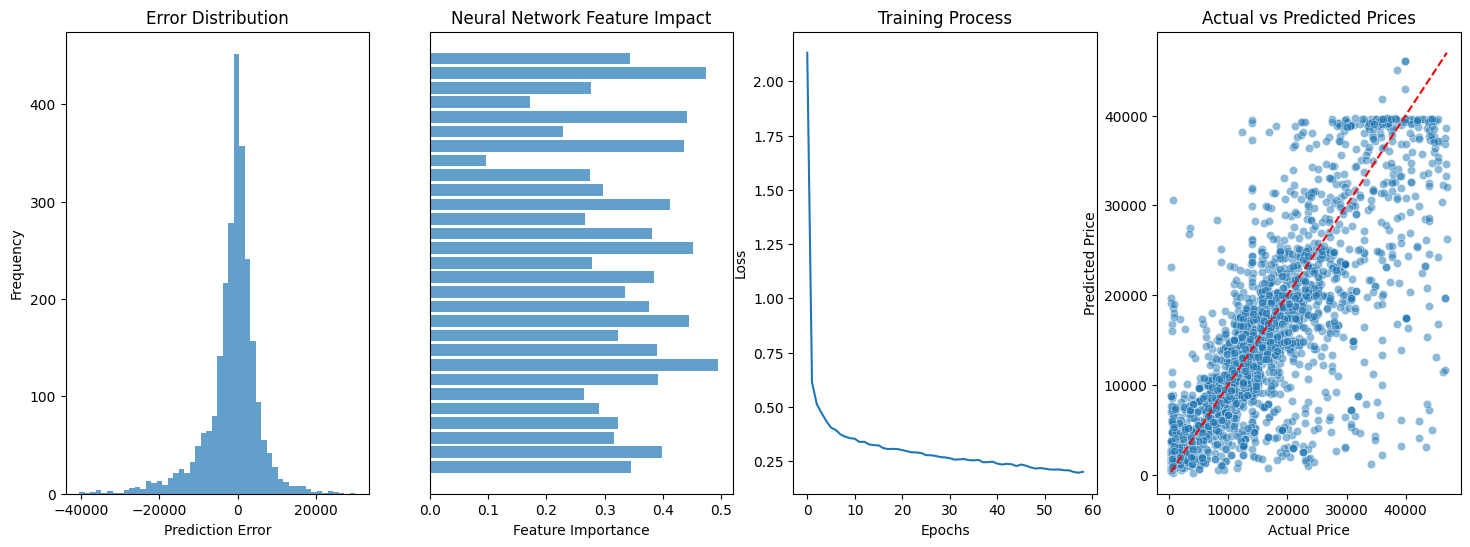

In [ ]:
# 可视化改进
plt.figure(figsize=(18, 6))

# 1. 预测误差分布
plt.subplot(1, 4, 1)
errors = y_pred_exp - y_test_exp
plt.hist(errors, bins=50, alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution')

# 2. 特征重要性（基于权重）
input_dim = best_model.named_steps['preprocessor'].transform(X_train[:1]).shape[1]
weights = best_model.named_steps['regressor'].coefs_[0]
importance = np.mean(np.abs(weights), axis=1)

plt.subplot(1, 4, 2)
plt.barh(range(input_dim), importance, alpha=0.7)
plt.yticks([])  # 隐藏具体特征名（维度较高）
plt.xlabel('Feature Importance')
plt.title('Neural Network Feature Impact')

# 3. 学习曲线
plt.subplot(1, 4, 3)
plt.plot(best_model.named_steps['regressor'].loss_curve_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Process')

# 实际vs预测
plt.subplot(1, 4, 4)
sns.scatterplot(x=y_test_exp, y=y_pred_exp, alpha=0.5)
plt.plot([y_test_exp.min(), y_test_exp.max()], 
             [y_test_exp.min(), y_test_exp.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')

plt.tight_layout()
plt.show()

In [153]:
# # 定义Optuna优化目标函数
# def objective(trial, X, y):
#     params = {
#         'hidden_layer_sizes': trial.suggest_categorical(
#             'hidden_layer_sizes', 
#             [(128, 64), (256, 128), (256, 128, 64)]
#         ),
#         'activation': trial.suggest_categorical(
#             'activation', 
#             ['relu', 'tanh', 'logistic']
#         ),
#         'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
#         'learning_rate_init': trial.suggest_float(
#             'learning_rate_init', 1e-4, 0.1, log=True  # 参数名修正
#         ),
#         'learning_rate': trial.suggest_categorical(
#             'learning_rate', 
#             ['constant', 'invscaling', 'adaptive']     # 策略参数
#         ),
#         'batch_size': trial.suggest_categorical(
#             'batch_size', [64, 128, 256]
#         ),
#         'solver': trial.suggest_categorical(
#             'solver', ['adam', 'sgd']
#         )
#     }
    
#     model = Pipeline([
#         ('preprocessor', preprocessor),
#         ('regressor', MLPRegressor(
#             **params,
#             early_stopping=True,
#             max_iter=500,
#             random_state=42
#         ))
#     ])
    
#     # 5折交叉验证
#     cv_scores = cross_val_score(
#         model, X, y, 
#         cv=5,
#         scoring='neg_root_mean_squared_error',
#         n_jobs=-1
#     )
    
#     return -np.mean(cv_scores)

In [154]:
# # 创建Optuna研究
# study = optuna.create_study(direction='minimize')

In [155]:
# # 执行优化（10次试验）
# study.optimize(
#     partial(objective, X=X_train, y=y_train), 
#     n_trials=1,
#     n_jobs=1,  # 避免与交叉验证的并行冲突
#     show_progress_bar=True
# )

In [156]:
# # 输出最佳参数
# print("\n最佳参数组合:")
# print(study.best_params)
# print(f"最佳RMSE: {study.best_value:.4f}")

In [157]:
# # 用最佳参数重新训练模型
# best_model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('regressor', MLPRegressor(
#         **study.best_params,
#         early_stopping=True,
#         max_iter=1000,  # 增加迭代次数确保收敛
#         random_state=42
#     ))
# ])